In [76]:
data_dir = '/home/mjehangir/telomere-sv-analysis/data/'

In [77]:
setwd(data_dir)

In [78]:
# Load necessary libraries
library(openxlsx)
library(dplyr)
library(tidyr)
library(ggplot2)
library(ComplexHeatmap)
library(circlize)
library(scales)

In [79]:
# Load the data from your txt file
file_path <- "./severus_somatic_sv.tsv"
data <- read.table(file_path, header = TRUE, sep = "\t")
head(data)

,chr,start,end,size,type,sample
,<chr>,<int>,<int>,<int>,<chr>,<chr>
1,chr1,1414067,1415349,1282,DEL,2436A
2,chr1,3010201,3010202,3771,INS,2436A
3,chr1,12524812,12554643,29831,DEL,2436A
4,chr1,16152446,16152447,368,INS,2436A
5,chr1,21257920,21257921,0,BND,2436A
6,chr1,34498454,34509010,10556,DEL,2436A


In [80]:
library(dplyr)

# Step 1: Create a unique SV ID
data <- data %>%
  mutate(SV_id = paste(chr, start, end, type, sep = "_"))

# Step 2: Count how many unique samples each SV appears in
sv_sample_counts <- data %>%
  distinct(SV_id, sample) %>%
  group_by(SV_id) %>%
  summarise(shared_in = n(), .groups = "drop")

# Step 3: Filter SVs shared across all 20 samples
shared_svs <- sv_sample_counts %>%
  filter(shared_in == 20)

# Step 4: Get full details of shared SVs including size
shared_sv_list <- data %>%
  filter(SV_id %in% shared_svs$SV_id) %>%
  distinct(SV_id, chr, start, end, size, type)

# Step 5: Print the result
print(shared_sv_list)


                         SV_id  chr     start       end size type
1 chr8_112191464_112192351_INV chr8 112191464 112192351  887  INV


In [81]:

data <- data %>%
  dplyr::rename(filename = sample)
head(data)

,chr,start,end,size,type,filename,SV_id
,<chr>,<int>,<int>,<int>,<chr>,<chr>,<chr>
1,chr1,1414067,1415349,1282,DEL,2436A,chr1_1414067_1415349_DEL
2,chr1,3010201,3010202,3771,INS,2436A,chr1_3010201_3010202_INS
3,chr1,12524812,12554643,29831,DEL,2436A,chr1_12524812_12554643_DEL
4,chr1,16152446,16152447,368,INS,2436A,chr1_16152446_16152447_INS
5,chr1,21257920,21257921,0,BND,2436A,chr1_21257920_21257921_BND
6,chr1,34498454,34509010,10556,DEL,2436A,chr1_34498454_34509010_DEL


In [82]:
data <- data %>%
  #mutate(size = abs(as.numeric(end) - as.numeric(start))) %>%  # Recalculate size in base pairs
  filter(size > 50)  # Only keep rows where the size is greater than 0

# Show the first few rows of the data
head(data)



,chr,start,end,size,type,filename,SV_id
,<chr>,<int>,<int>,<int>,<chr>,<chr>,<chr>
1,chr1,1414067,1415349,1282,DEL,2436A,chr1_1414067_1415349_DEL
2,chr1,3010201,3010202,3771,INS,2436A,chr1_3010201_3010202_INS
3,chr1,12524812,12554643,29831,DEL,2436A,chr1_12524812_12554643_DEL
4,chr1,16152446,16152447,368,INS,2436A,chr1_16152446_16152447_INS
5,chr1,34498454,34509010,10556,DEL,2436A,chr1_34498454_34509010_DEL
6,chr1,35019427,35019801,374,DUP,2436A,chr1_35019427_35019801_DUP


In [83]:
library(dplyr)
library(ggplot2)

# Custom colors
sv_colors <- c("DEL" = "skyblue3",
               "DUP" = "orangered",
               "BND" = "pink",
               "INV" = "orange",
               "INS" = "green4")

# Count total SVs per type across cohort
sv_type_total <- data %>%
  group_by(type) %>%
  summarize(total_count = n(), .groups = "drop")

# Calculate median + IQR threshold for significance
median_count <- median(sv_type_total$total_count)
iqr_count <- IQR(sv_type_total$total_count)
threshold_high <- median_count + 1.5 * iqr_count

# Flag significant SVs (BND or above threshold)
sv_type_total <- sv_type_total %>%
  mutate(significant = ifelse(total_count > threshold_high | type == "BND", TRUE, FALSE))
options(repr.plot.width = 5, repr.plot.height = 5, repr.plot.res = 200)

# Plot with total counts and significance stars
r<- ggplot(sv_type_total, aes(x = reorder(type, -total_count), y = total_count, fill = type)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = total_count), vjust = -0.5, size = 5) +  # total counts
  geom_text(data = sv_type_total %>% filter(significant),
            aes(label = "*"), vjust = -1.5, size = 8, color = "red") +  # significance stars
  scale_fill_manual(values = sv_colors) +
  labs(x = "SV Type", y = "Total Count",
       fill = "SV Type",
       title = "Total SV counts per type across cohort\nRed star = Significant (high or BND)") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))








In [84]:
library(dplyr)
library(ggplot2)

# Count total SVs per sample
sv_counts_sample <- data %>%
  group_by(filename) %>%
  summarize(total_SVs = n(), .groups = "drop")

# Calculate cohort mean
mean_SVs <- mean(sv_counts_sample$total_SVs)
options(repr.plot.width = 8, repr.plot.height = 5, repr.plot.res = 200)

# Plot total SVs per sample with cohort mean line
p<- ggplot(sv_counts_sample, aes(x = reorder(filename, -total_SVs), y = total_SVs)) +
  geom_bar(stat = "identity", fill = "steelblue") +
  geom_hline(yintercept = mean_SVs, linetype = "dashed", color = "red", size = 1) +
  geom_text(aes(label = total_SVs), vjust = -0.5, size = 4) +  # show counts
  labs(x = "Sample", y = "Total SV Count",
       title = "Total SVs per sample with cohort mean (red dashed line)") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))


In [75]:
outdir <- "/home/mjehangir/telomere-sv-analysis/plots/fig2/severus/"
dir.create(outdir, showWarnings = FALSE, recursive = TRUE)
ggsave(file.path(outdir, "severus_total_SV_counts_per_patient.pdf"), plot = p, width = 7, height = 5, dpi = 200)
ggsave(file.path(outdir, "severus_total_SV_counts_per_sv_type.pdf"), plot = r, width = 7, height = 5, dpi = 200)


In [17]:
library(ggplot2)
library(dplyr)
library(forcats)
library(scales)


# Custom colors
sv_colors <- c("DEL" = "skyblue3",
               "DUP" = "orangered",
               "BND" = "pink",
               "INV" = "orange",
              "INS" = "green4")

#–––––––––––––––––––––––––––––––––––––
# p1: SV counts per sample (sorted & stacked)
#–––––––––––––––––––––––––––––––––––––
# Order samples by total SV counts
sample_order <- data %>%
  count(filename) %>%
  arrange(desc(n)) %>%
  pull(filename)

p1 <- data %>%
  count(filename, type) %>%
  mutate(filename = factor(filename, levels = sample_order)) %>%
  ggplot(aes(x = filename, y = n, fill = type)) +
  geom_bar(stat = "identity", position = "stack", color = "black", width = 1) +
  scale_y_continuous(expand = expansion(mult = c(0, 0.05)), 
                     breaks = pretty_breaks(n = 6)) +
  scale_fill_manual(values = sv_colors) +
  labs(x = "Sample", y = "Number of SVs",
       title = "Tier I Structural Variants per Sample") +
  theme_bw(base_size = 14) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, face = "bold", size = 10),
    axis.title.y = element_text(face = "bold"),
    plot.title  = element_text(face = "bold", hjust = 0.5),
    legend.title = element_blank()
  )

#–––––––––––––––––––––––––––––––––––––
# p2: Size distribution separate for each type
#–––––––––––––––––––––––––––––––––––––
# Define size bins
#data_bins <- data_noINS %>%
 # mutate(size_bin = cut(size,
  #                      breaks = c(0, 1e3, 1e4, 1e5, 1e6, Inf),
   #                     labels = c("<1 kb", "1–10 kb", "10–100 kb", "100 kb–1 Mb", ">1 Mb"),
    #                    right = FALSE))


data_bins <- data %>%
  mutate(
    size_bin = cut(
      size,
      breaks = c(0, 1e2, 5e2, 1e3, 5e3, 1e4, 1e5, 1e6, 1e7, Inf),
      labels = c("<0.1 kb", "0.1–0.5 kb", "0.5–1 kb", "1–5 kb", "5–10 kb",
                 "10–100 kb", "0.1–1 Mb", "1–10 Mb", ">10 Mb"),
      right = FALSE,
      include.lowest = TRUE
    )
  )

In [18]:
head(data_bins)

,chr,start,end,size,type,filename,SV_id,size_bin
,<chr>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<fct>
1,chr1,1414067,1415349,1282,DEL,2436A,chr1_1414067_1415349_DEL,1–5 kb
2,chr1,3010201,3010202,3771,INS,2436A,chr1_3010201_3010202_INS,1–5 kb
3,chr1,12524812,12554643,29831,DEL,2436A,chr1_12524812_12554643_DEL,10–100 kb
4,chr1,16152446,16152447,368,INS,2436A,chr1_16152446_16152447_INS,0.1–0.5 kb
5,chr1,34498454,34509010,10556,DEL,2436A,chr1_34498454_34509010_DEL,10–100 kb
6,chr1,35019427,35019801,374,DUP,2436A,chr1_35019427_35019801_DUP,0.1–0.5 kb


In [19]:
p2 <- data_bins %>%
  count(size_bin, type) %>%
  ggplot(aes(x = size_bin, y = n, fill = type)) +
  geom_bar(stat = "identity", color = "black", width = 0.7) +
  scale_y_continuous(expand = expansion(mult = c(0, 0.05)),
                     breaks = scales::pretty_breaks(n = 6)) +
  scale_fill_manual(values = sv_colors) +
  facet_wrap(~ type, scales = "free_y", nrow = 1) +  # <- one row
  labs(x = "SV Size Bin", y = "Number of SVs",
       title = "Size Distribution of Structural Variants by Class") +
  theme_bw(base_size = 14) +
  theme(
    axis.text.x  = element_text(angle = 90, vjust = 0.5, hjust = 1, face = "bold", size = 9),
    axis.title.y = element_text(face = "bold"),
    plot.title   = element_text(face = "bold", hjust = 0.5),
    legend.position = "none",
    plot.margin = margin(t = 10, r = 10, b = 40, l = 10)
  )


In [20]:
# Output directory
outdir <- "/home/mjehangir/telomere-sv-analysis/plots/fig2/severus/"
dir.create(outdir, showWarnings = FALSE, recursive = TRUE)
ggsave(file.path(outdir, "total_SV_count_v2.pdf"), plot = p1, width = 7, height = 5, dpi = 200)
ggsave(file.path(outdir, "size_distribution_v2.pdf"), plot = p2, width = 12, height = 4, dpi = 200)


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for '0.1–0.5 kb' in 'mbcsToSbcs': - substituted for – (U+2013)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for '0.5–1 kb' in 'mbcsToSbcs': - substituted for – (U+2013)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for '1–5 kb' in 'mbcsToSbcs': - substituted for – (U+2013)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for '5–10 kb' in 'mbcsToSbcs': - substituted for – (U+2013)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for '10–100 kb' in 'mbcsToSbcs': - substituted for – (U+2013)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for '0.1–1 Mb' in 'mbcsToSbcs': - substituted for – (U+2013)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for '1–10 Mb' in 'mbcsToSb

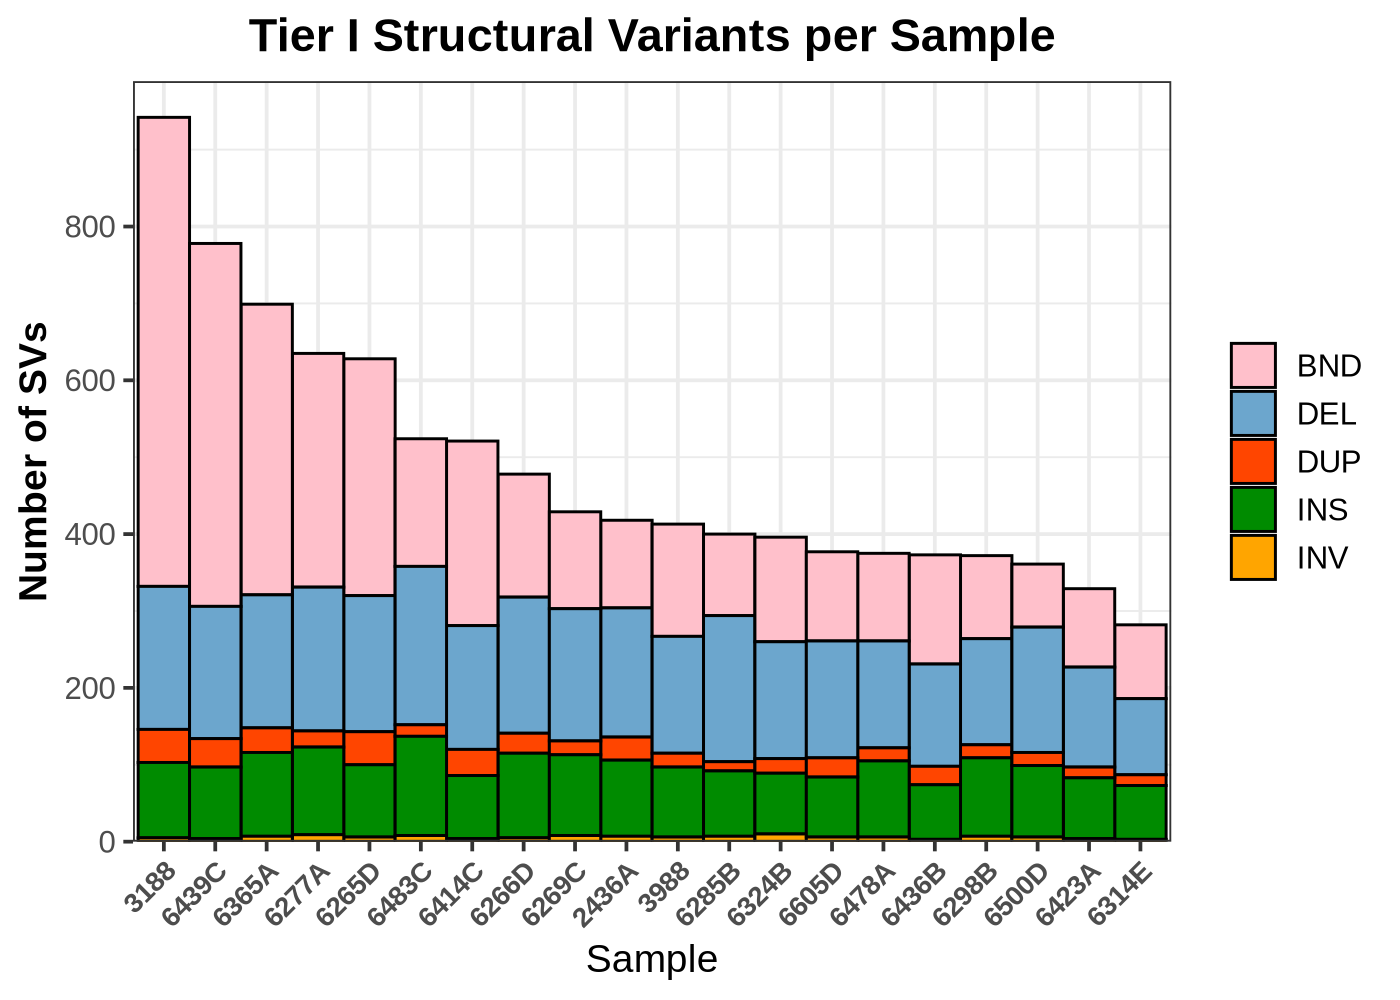

In [21]:
options(repr.plot.width = 7, repr.plot.height = 5, repr.plot.res = 200)

# Show plots
print(p1)

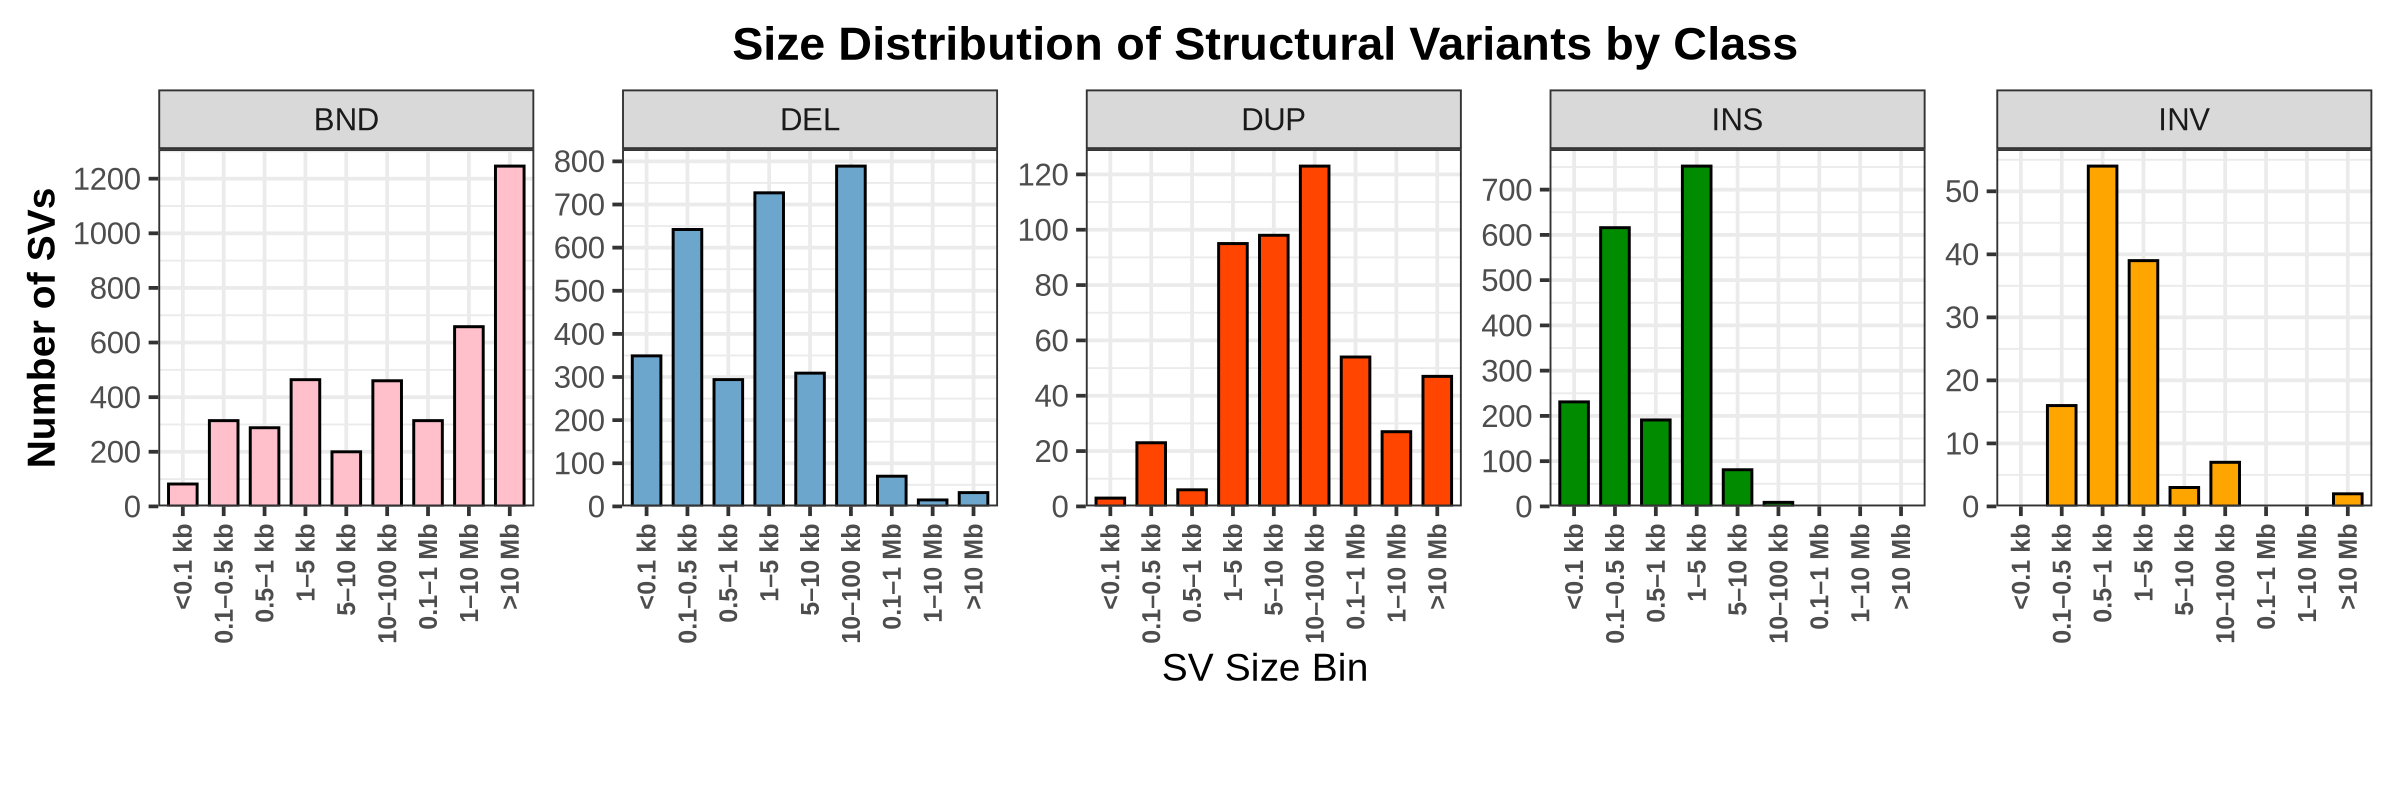

In [22]:
options(repr.plot.width = 12, repr.plot.height = 4, repr.plot.res = 200)

print(p2)

`summarise()` has grouped output by 'filename'. You can override using the
`.groups` argument.


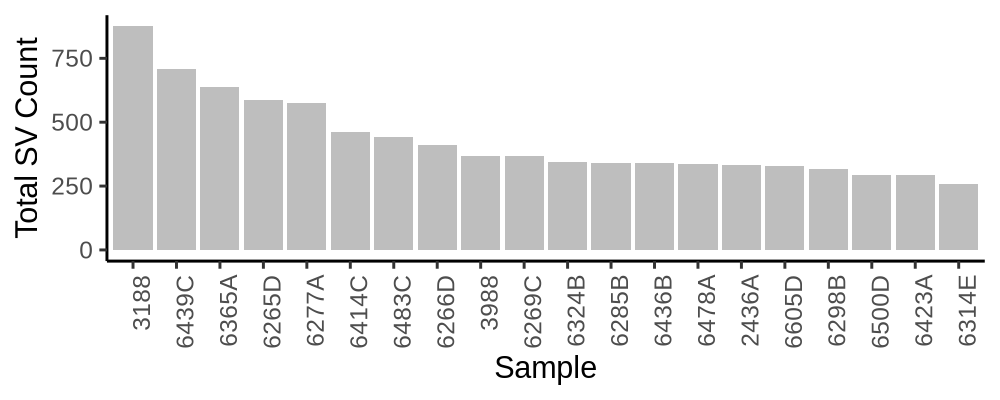

`summarise()` has grouped output by 'filename'. You can override using the
`.groups` argument.


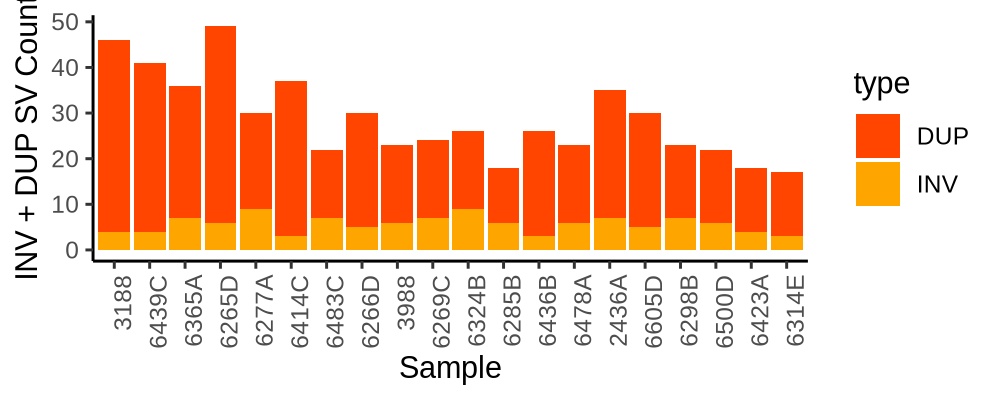

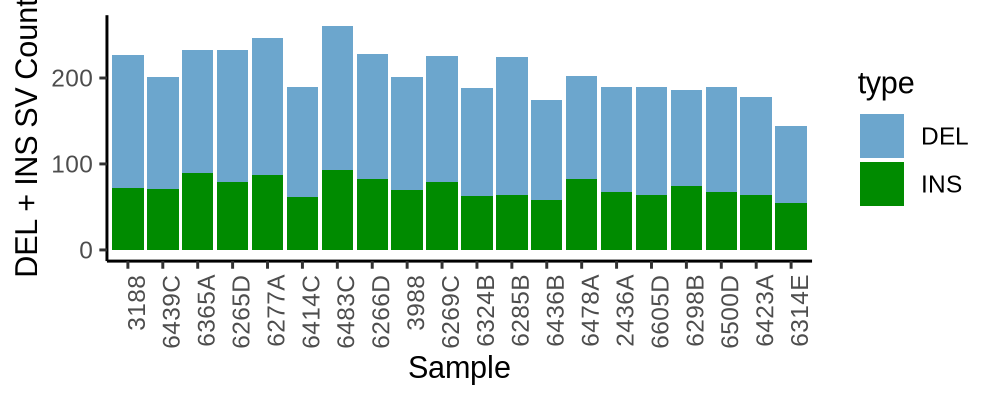

In [23]:

# Step 1: Filter the data to keep only chromosomes from chr1 to chr22
data <- data %>%
  filter(chr %in% paste0("chr", 1:22))  # Filter out chrX, chrY, chrM

# Step 2: Total SVs per sample bar plot (raw count, ordered descending)
total_SVs <- data %>%
  group_by(filename) %>%
  summarize(Total_SV = n())  # Count number of SVs per sample

# Sort samples by total SV count (descending order)
sorted_samples <- total_SVs %>%
  arrange(desc(Total_SV)) %>%
  pull(filename)

options(repr.plot.width = 5, repr.plot.height = 2, repr.plot.res = 200)

# Barplot for total SV count per sample (ordered descending)
ggplot(total_SVs, aes(x = factor(filename, levels = sorted_samples), y = Total_SV)) +
  geom_bar(stat = "identity", fill = "grey") +
  labs(x = "Sample", y = "Total SV Count") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))  # Rotate x-axis labels for clarity


# Step 3: Stacked bar plot by SV types (combining INV + DUP and DEL + INS into separate plots)
# INV + DUP combined Plot
sv_types_INV_DUP <- data %>%
  filter(type %in% c("INV", "DUP")) %>%
  group_by(filename, type) %>%
  summarize(SV_count_type = n())  # Count number of INV and DUP SVs per sample

ggplot(sv_types_INV_DUP, aes(x = factor(filename, levels = sorted_samples), y = SV_count_type, fill = type)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = c("INV" = "orange", "DUP" = "orangered")) +
  labs(x = "Sample", y = "INV + DUP SV Count") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))  # Rotate x-axis labels for clarity


# DEL + INS combined Plot
sv_types_DEL_INS <- data %>%
  filter(type %in% c("DEL", "INS")) %>%
  group_by(filename, type) %>%
  summarize(SV_count_type = n())  # Count number of DEL and INS SVs per sample

ggplot(sv_types_DEL_INS, aes(x = factor(filename, levels = sorted_samples), y = SV_count_type, fill = type)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = c("DEL" = "skyblue3", "INS" = "green4")) +
  labs(x = "Sample", y = "DEL + INS SV Count") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))  # Rotate x-axis labels for clarity

In [24]:
library(ggplot2)
library(dplyr)

# Output directory
outdir <- "/home/mjehangir/telomere-sv-analysis/plots/fig2/severus/"
dir.create(outdir, showWarnings = FALSE, recursive = TRUE)

# -----------------------------
# 1. Total SV count barplot
p1 <- ggplot(total_SVs, aes(x = factor(filename, levels = sorted_samples), y = Total_SV)) +
  geom_bar(stat = "identity", fill = "grey") +
  labs(x = "Sample", y = "Total SV Count") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))

ggsave(file.path(outdir, "total_SV_count.pdf"), plot = p1, width = 5, height = 2.5, dpi = 200)


# -----------------------------
# 2. INV + DUP combined
sv_types_INV_DUP <- data %>%
  filter(type %in% c("INV", "DUP")) %>%
  group_by(filename, type) %>%
  summarize(SV_count_type = n(), .groups = "drop")

p2 <- ggplot(sv_types_INV_DUP, aes(x = factor(filename, levels = sorted_samples), y = SV_count_type, fill = type)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = c("INV" = "orange", "DUP" = "orangered")) +
  labs(x = "Sample", y = "INV + DUP SV Count") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))

ggsave(file.path(outdir, "INV_DUP_SV_count.pdf"), plot = p2, width = 5, height = 2.5, dpi = 200)


# -----------------------------
# 3. DEL + INS combined
sv_types_DEL_INS <- data %>%
  filter(type %in% c("DEL", "INS")) %>%
  group_by(filename, type) %>%
  summarize(SV_count_type = n(), .groups = "drop")

p3 <- ggplot(sv_types_DEL_INS, aes(x = factor(filename, levels = sorted_samples), y = SV_count_type, fill = type)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = c("DEL" = "skyblue3", "INS" = "green4")) +
  labs(x = "Sample", y = "DEL + INS SV Count") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))

ggsave(file.path(outdir, "DEL_INS_SV_count.pdf"), plot = p3, width = 5, height = 2.5, dpi = 200)


In [25]:
head(total_SVs)

filename,Total_SV
<chr>,<int>
2436A,333
3188,875
3988,368
6265D,585
6266D,410
6269C,368


In [26]:
total_svs_sorted <- total_SVs %>%
  arrange(desc(Total_SV))

print(total_svs_sorted)

# A tibble: 20 × 2
   filename Total_SV
   <chr>       <int>
 1 3188          875
 2 6439C         710
 3 6365A         636
 4 6265D         585
 5 6277A         576
 6 6414C         462
 7 6483C         442
 8 6266D         410
 9 3988          368
10 6269C         368
11 6324B         346
12 6285B         340
13 6436B         340
14 6478A         335
15 2436A         333
16 6605D         329
17 6298B         317
18 6500D         294
19 6423A         292
20 6314E         257


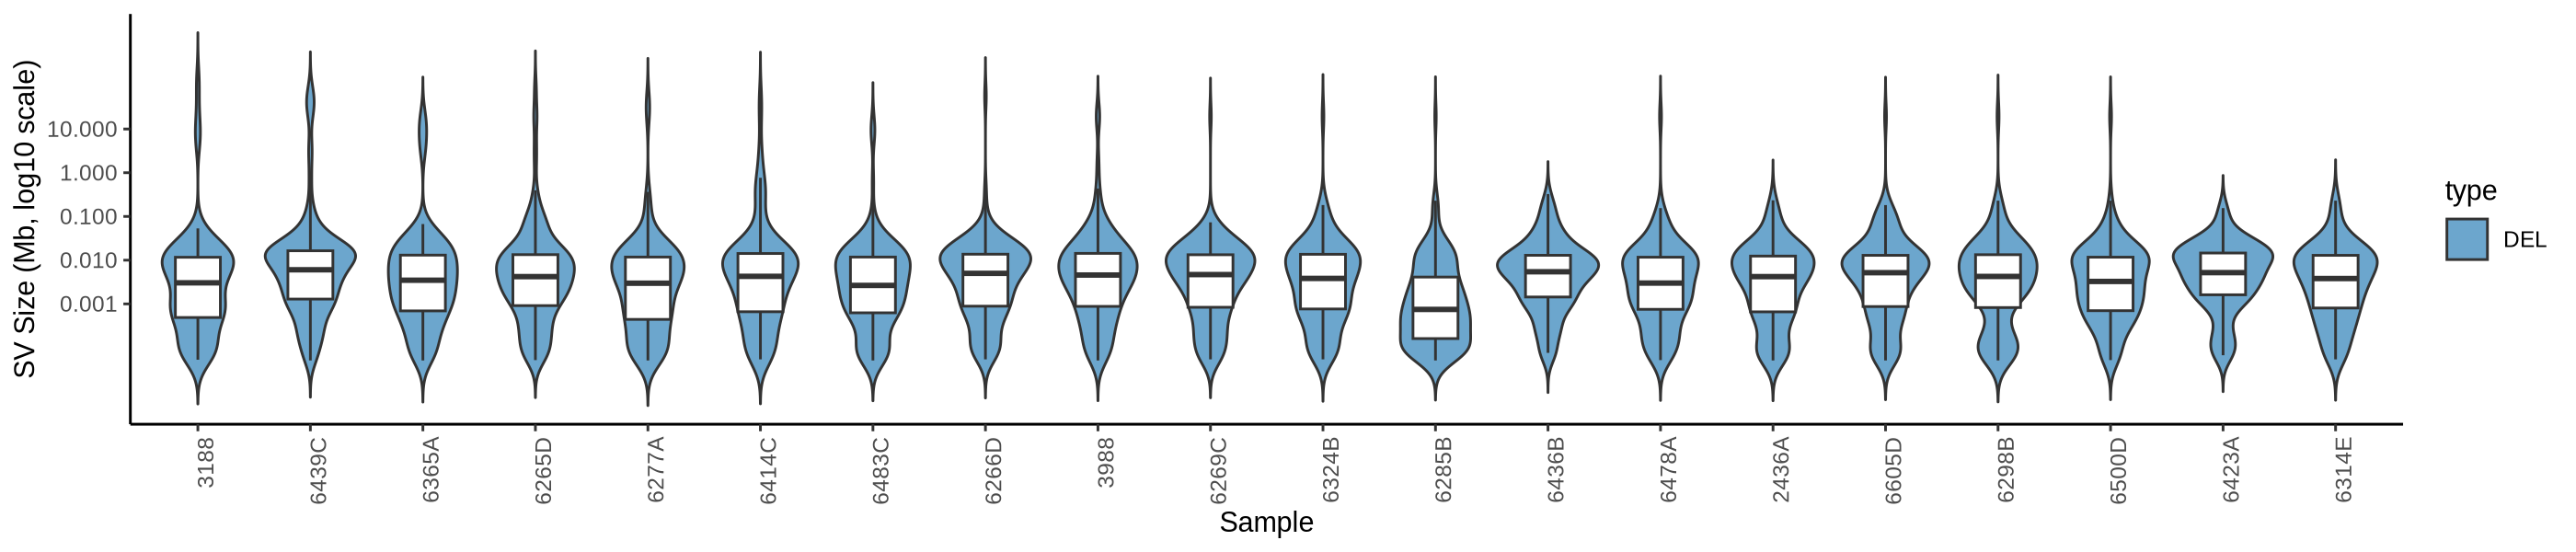

In [27]:

options(repr.plot.width = 14, repr.plot.height = 3, repr.plot.res = 200)

del_violin_plot<-ggplot(data %>% filter(type == "DEL"), 
       aes(x = factor(filename, levels = sorted_samples), y = size/1e6, fill = type)) +
  geom_violin(trim = FALSE) +
  geom_boxplot(width = 0.4, fill = "white", outlier.shape = NA) +
  scale_y_continuous(trans = 'log10', 
                     breaks = c(0.001, 0.01, 0.1, 1, 10), 
                     labels = scales::comma) +
  scale_fill_manual(values = c("DEL" = "skyblue3")) +
  labs(x = "Sample", y = "SV Size (Mb, log10 scale)") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))
print(del_violin_plot)
# Save the plot to the specified directory
ggsave("/home/mjehangir/telomere-sv-analysis/plots/fig2/severus/DEL_SV_Size_violin_v2.pdf", plot = del_violin_plot, height = 6, width = 14)


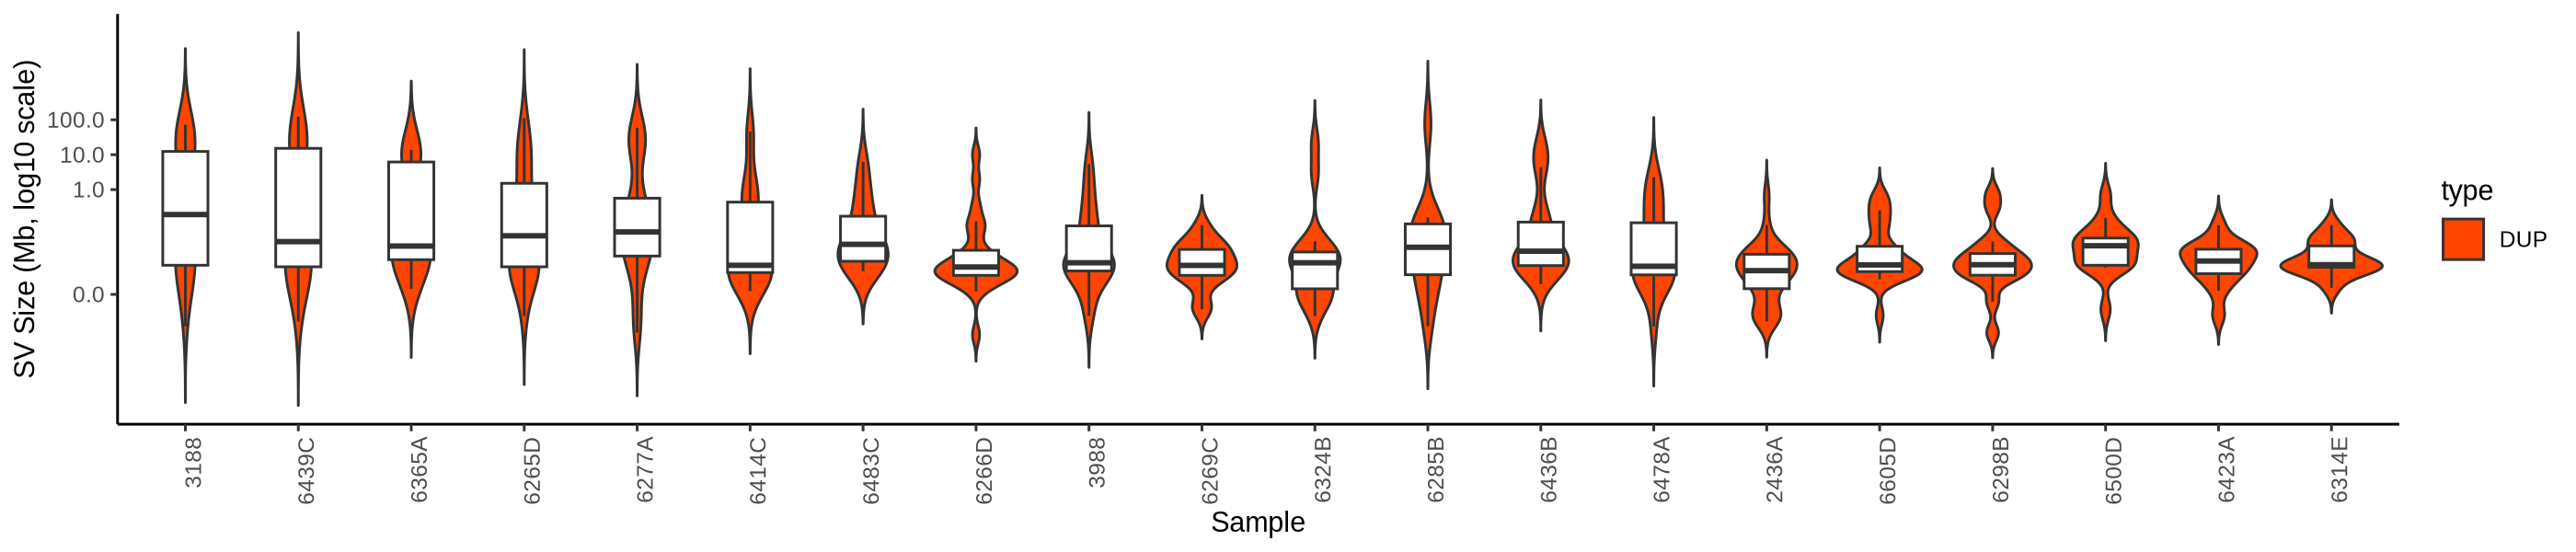

In [28]:
dup_violin_plot<-ggplot(data %>% filter(type == "DUP"), 
       aes(x = factor(filename, levels = sorted_samples), y = size/1e6, fill = type)) +
  geom_violin(trim = FALSE) +
  geom_boxplot(width = 0.4, fill = "white", outlier.shape = NA) +
  scale_y_continuous(trans = 'log10', 
                     breaks = c(0.001, 1, 10, 100), 
                     labels = scales::comma) +
  scale_fill_manual(values = c("DUP" = "orangered")) +
  labs(x = "Sample", y = "SV Size (Mb, log10 scale)") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))
ggsave("/home/mjehangir/telomere-sv-analysis/plots/fig2/severus/DUP_SV_Size_violin_v2.pdf", plot = dup_violin_plot, height = 6, width = 14)
dup_violin_plot

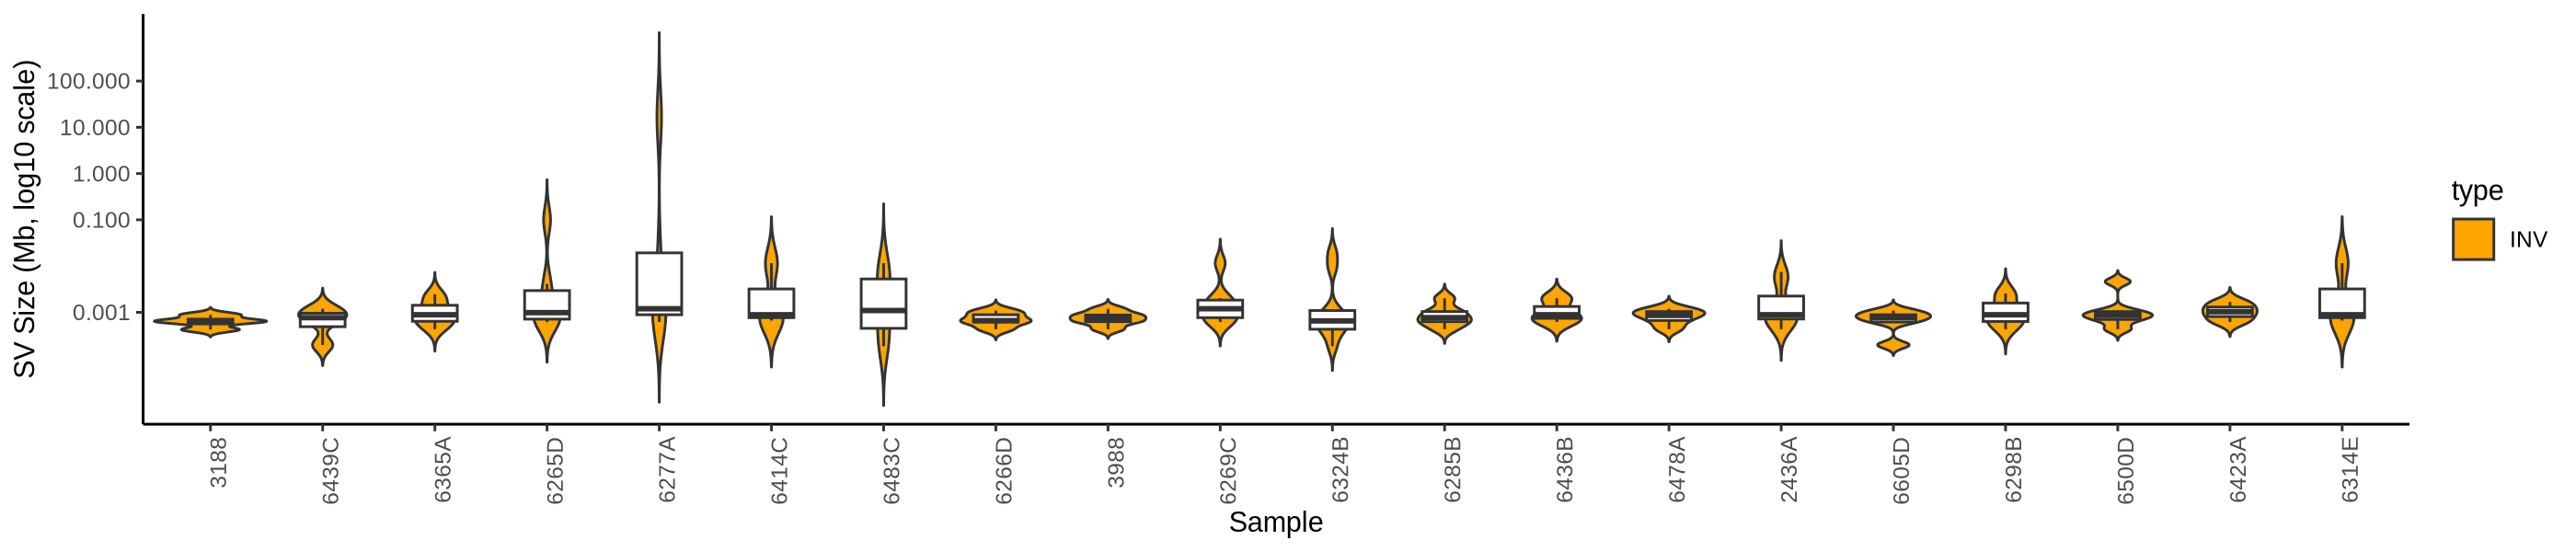

In [29]:
inv_violin_plot<-ggplot(data %>% filter(type == "INV"), 
       aes(x = factor(filename, levels = sorted_samples), y = size/1e6, fill = type)) +
  geom_violin(trim = FALSE, width = 1) +
  geom_boxplot(width = 0.4, fill = "white", outlier.shape = NA) +
  scale_y_continuous(trans = 'log10', 
                     breaks = c(0.001, 0.1, 1, 10, 100), 
                     labels = scales::comma) +
  scale_fill_manual(values = c("INV" = "orange")) +
  labs(x = "Sample", y = "SV Size (Mb, log10 scale)") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))
ggsave("/home/mjehangir/telomere-sv-analysis/plots/fig2/severus/INV_SV_Size_violin_v2.pdf", plot = inv_violin_plot, height = 6, width = 14)
inv_violin_plot

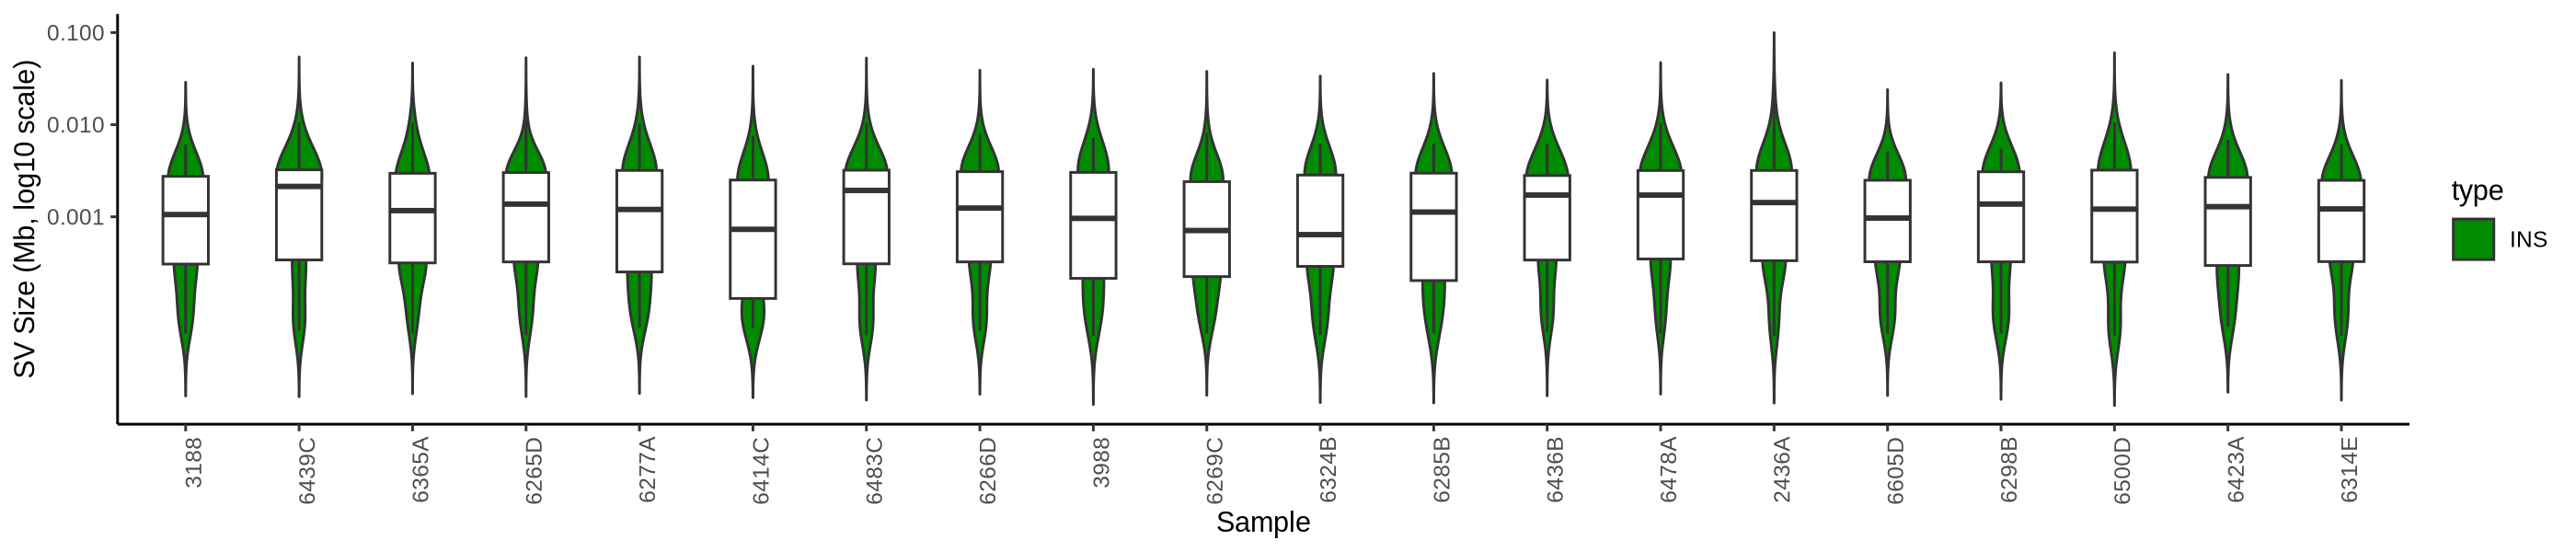

In [30]:
ins_violin_plot<-ggplot(data %>% filter(type == "INS"), 
       aes(x = factor(filename, levels = sorted_samples), y = size/1e6, fill = type)) +
  geom_violin(trim = FALSE, width = 0.4) +
  geom_boxplot(width = 0.4, fill = "white", outlier.shape = NA) +
  scale_y_continuous(trans = 'log10', 
                     breaks = c(0.001, 0.01, 0.1, 1), 
                     labels = scales::comma) +
  scale_fill_manual(values = c("INS" = "green4")) +
  labs(x = "Sample", y = "SV Size (Mb, log10 scale)") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))
#ggsave("/home/mjehangir/glioma_manuscript/manuscript_data/plots_f1/INS_SV_Size_violin_v2.pdf", plot = ins_violin_plot, height = 6, width = 14)
ins_violin_plot

In [31]:
# Filter out BND SVs
data_filtered <- data %>% filter(type != "BND")

# Ensure correct column name for SV length
# If 'SV_length' does not exist, replace with the actual column name (e.g., 'size')
sv_summary <- data_filtered %>%
  group_by(filename, type) %>%
  summarize(SV_length = sum(size), .groups = "drop")  # Change 'size' if needed

# Convert SV length to log10 scale
sv_summary <- sv_summary %>%
  mutate(SV_length_log10 = log10(SV_length))

In [32]:
head(data_filtered)

,chr,start,end,size,type,filename,SV_id
,<chr>,<int>,<int>,<int>,<chr>,<chr>,<chr>
1,chr1,1414067,1415349,1282,DEL,2436A,chr1_1414067_1415349_DEL
2,chr1,3010201,3010202,3771,INS,2436A,chr1_3010201_3010202_INS
3,chr1,12524812,12554643,29831,DEL,2436A,chr1_12524812_12554643_DEL
4,chr1,16152446,16152447,368,INS,2436A,chr1_16152446_16152447_INS
5,chr1,34498454,34509010,10556,DEL,2436A,chr1_34498454_34509010_DEL
6,chr1,35019427,35019801,374,DUP,2436A,chr1_35019427_35019801_DUP


In [33]:
nrow(data_filtered)

[1] 4683


	Friedman rank sum test

data:  count and type and filename
Friedman chi-squared = 60, df = 3, p-value = 5.878e-13



Warning message in wilcox.test.default(sv_counts_wide[[pair[1]]], sv_counts_wide[[pair[2]]], :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(sv_counts_wide[[pair[1]]], sv_counts_wide[[pair[2]]], :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(sv_counts_wide[[pair[1]]], sv_counts_wide[[pair[2]]], :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(sv_counts_wide[[pair[1]]], sv_counts_wide[[pair[2]]], :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(sv_counts_wide[[pair[1]]], sv_counts_wide[[pair[2]]], :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(sv_counts_wide[[pair[1]]], sv_counts_wide[[pair[2]]], :
“cannot compute exact p-value with ties”


  Comparison P_Value_Adjusted
1 DEL vs DUP     0.0005717359
2 DEL vs INS     0.0005717359
3 DEL vs INV     0.0005717359
4 DUP vs INS     0.0005725398
5 DUP vs INV     0.0005637430
6 INS vs INV     0.0005709327


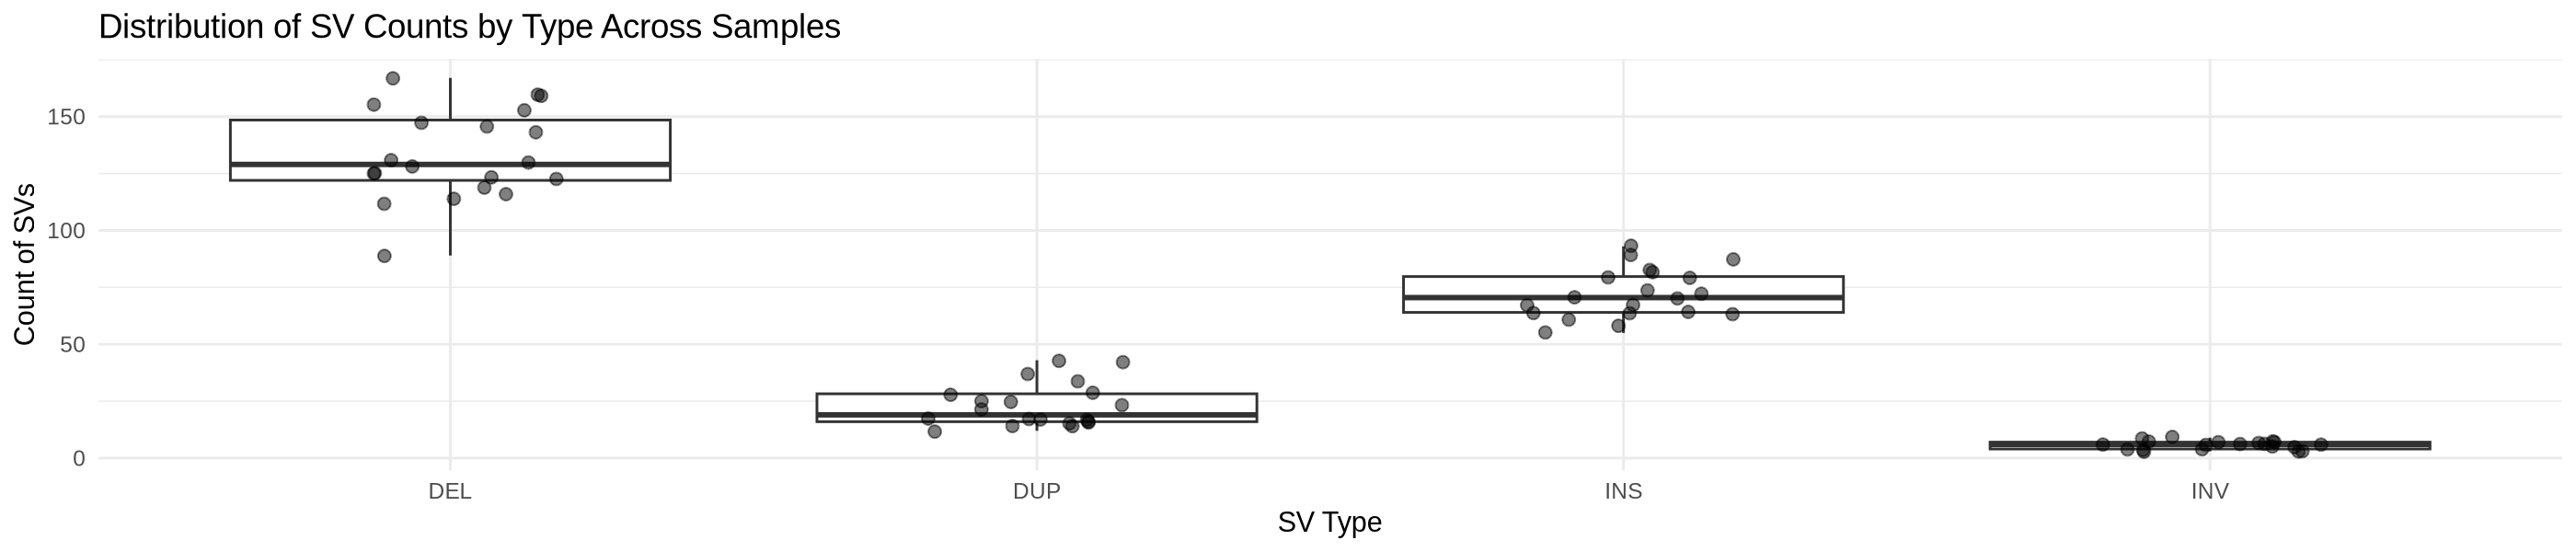

In [34]:
# Load libraries
library(dplyr)
library(tidyr)
library(ggplot2)

# Step 1: Aggregate counts
sv_counts <- data_filtered %>%
  group_by(filename, type) %>%
  summarise(count = n(), .groups = "drop")

# Step 2: Include zeros for missing combinations
sv_counts_complete <- sv_counts %>%
  complete(filename, type, fill = list(count = 0))

# Step 3: Create boxplot
ggplot(sv_counts_complete, aes(x = type, y = count)) +
  geom_boxplot(outlier.shape = NA) +
  geom_jitter(width = 0.2, alpha = 0.5, size = 2) +
  labs(x = "SV Type", y = "Count of SVs", 
       title = "Distribution of SV Counts by Type Across Samples") +
  theme_minimal()

# Step 4: Statistical tests
# Friedman test
friedman_result <- friedman.test(count ~ type | filename, data = sv_counts_complete)
print(friedman_result)

# If Friedman test is significant, proceed with pairwise comparisons
if (friedman_result$p.value < 0.05) {
  sv_counts_wide <- sv_counts_complete %>%
    pivot_wider(names_from = type, values_from = count)
  types <- colnames(sv_counts_wide)[-1]
  pairs <- combn(types, 2, simplify = FALSE)
  p_values <- sapply(pairs, function(pair) {
    wilcox.test(sv_counts_wide[[pair[1]]], sv_counts_wide[[pair[2]]], paired = TRUE)$p.value
  })
  p_adjusted <- p.adjust(p_values, method = "bonferroni")
  results <- data.frame(
    Comparison = sapply(pairs, function(p) paste(p[1], "vs", p[2])),
    P_Value_Adjusted = p_adjusted
  )
  print(results)
}

Warning message in wilcox.test.default(c(123, 155, 131, 153, 146, 147, 159, 160, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(123, 155, 131, 153, 146, 147, 159, 160, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(123, 155, 131, 153, 146, 147, 159, 160, :
“cannot compute exact p-value with ties”
Warning message:
“Computation failed in `stat_signif()`.
Caused by error in `if (scales$x$map(comp[1]) == data$group[1] | manual) ...`:
! missing value where TRUE/FALSE needed”
Warning message in wilcox.test.default(c(123, 155, 131, 153, 146, 147, 159, 160, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(123, 155, 131, 153, 146, 147, 159, 160, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(123, 155, 131, 153, 146, 147, 159, 160, :
“cannot compute exact p-value with ties”
Warning message:
“Computation failed in `stat_signif()`.
Caused by error in `if

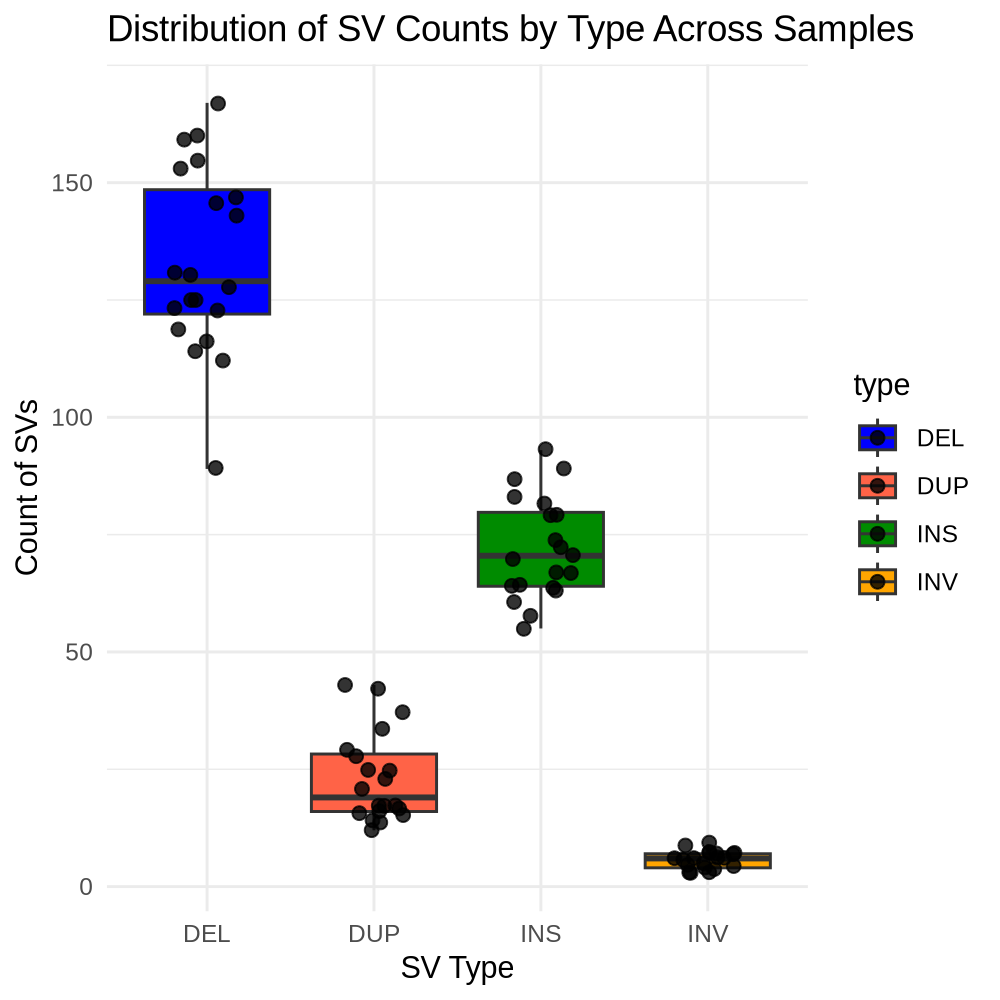

In [39]:
options(repr.plot.width = 5, repr.plot.height = 5, repr.plot.res = 200)

# Define specific colors for each SV type
colors <- c("DEL" = "blue", "DUP" = "tomato", "INV" = "orange", "INS" = "green4")

# Install and load ggpubr if you haven't already
# install.packages("ggpubr")
library(ggpubr)

# Define pairwise comparisons (all six pairs for four groups)
comparisons <- list(
  c("DEL", "DUP"), 
  c("DEL", "INV"), 
  c("DEL", "INS"),
  c("DUP", "INV"), 
  c("BND", "INS")
  #c("INV", "INS")
)

p <- ggplot(sv_counts_complete, aes(x = type, y = count, fill = type)) +
  geom_boxplot(outlier.shape = NA) +
  geom_jitter(width = 0.2, alpha = 0.8, size = 2) +
  stat_compare_means(comparisons = comparisons, method = "wilcox.test",
                     label = "p.signif", size = 5, exact = FALSE) +
  labs(x = "SV Type", y = "Count of SVs", 
       title = "Distribution of SV Counts by Type Across Samples") +
  scale_fill_manual(values = colors) +
  theme_minimal()

ggsave("/home/mjehangir/telomere-sv-analysis/plots/fig2/severus/Distribution_sv_types.pdf",
       plot = p, height = 8, width = 10, dpi = 300)
p

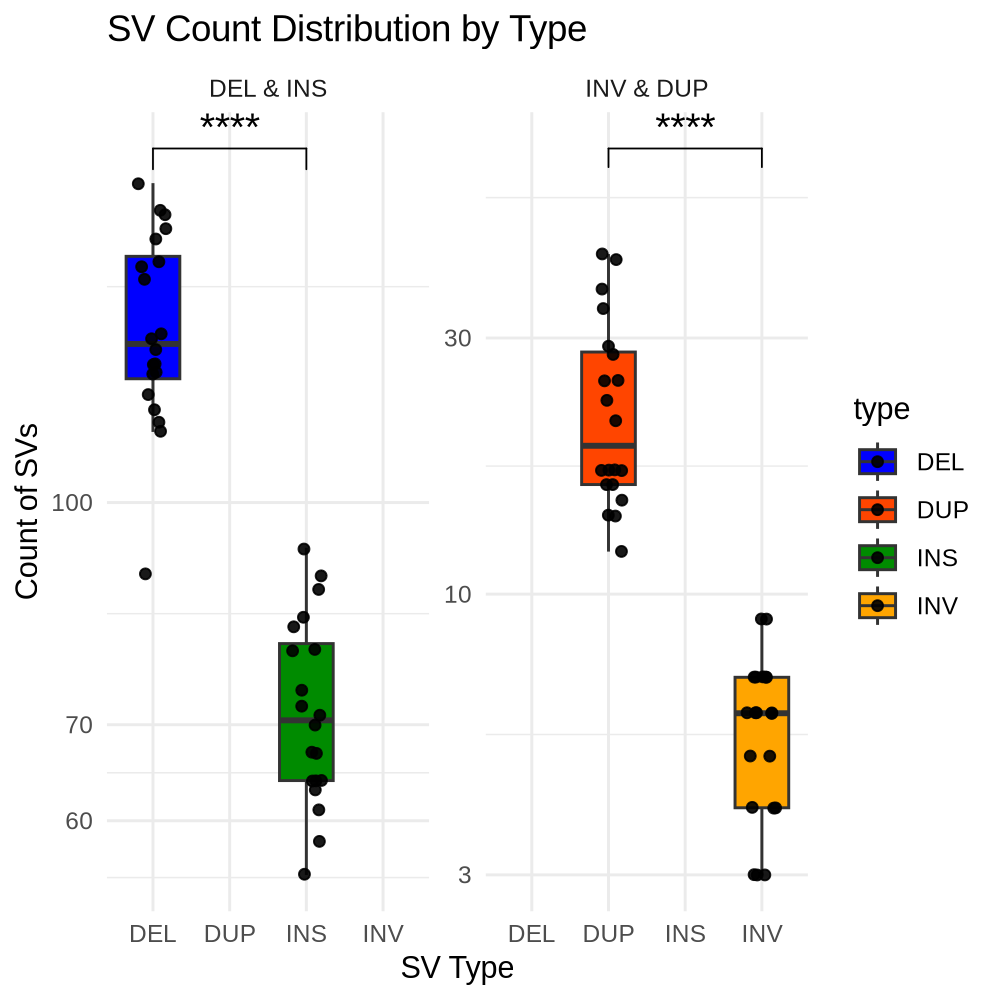

In [37]:
library(ggplot2)
library(ggpubr)

# Define colors for SV types
colors <- c("DEL" = "blue", "DUP" = "orangered", "INV" = "orange", "INS" = "green4")

# Define only the required pairwise comparisons
comparisons <- list(
  c("DEL", "INS"),
  c("INV", "DUP")
)

# Grouping for facet separation
sv_counts_complete$scale_group <- ifelse(sv_counts_complete$type %in% c("DEL", "INS"), "DEL & INS", "INV & DUP")

# Create the plot
ggplot(sv_counts_complete, aes(x = type, y = count, fill = type)) +
  geom_boxplot(outlier.shape = NA, width = 0.7) +  # Boxplot for distributions
  geom_jitter(width = 0.2, alpha = 0.9, size = 1.5) +  # Jitter points for low-count SVs
  stat_compare_means(comparisons = comparisons, method = "t.test", label = "p.signif", size = 5) +  # Wilcoxon test
  labs(x = "SV Type", y = "Count of SVs", title = "SV Count Distribution by Type") +
  scale_fill_manual(values = colors) +
  theme_minimal() +
  facet_wrap(~scale_group, scales = "free_y") +  # Separate DEL/INS and INV/DUP for clarity
  scale_y_log10()  # Log scale to make low-count SVs (DUP) visible



In [29]:
head(sv_counts_complete)

filename,type,count,scale_group
<chr>,<chr>,<int>,<chr>
2436A,DEL,123,DEL & INS
2436A,DUP,28,INV & DUP
2436A,INS,67,DEL & INS
2436A,INV,7,INV & DUP
3188,DEL,156,DEL & INS
3188,DUP,42,INV & DUP


In [33]:
plot_sv_histogram <- function(sv_type, color) {
  ggplot(data %>% filter(type == sv_type), 
         aes(x = size, fill = type)) +
    geom_histogram(binwidth = 0.1, alpha = 0.6, position = "identity", color = "black") +  # Histogram with binwidth of 0.1
    scale_x_continuous(trans = "log10", 
                       breaks = c(1, 10, 100, 1000, 10000, 100000, 1000000, 10000000, 100000000),  # Log scale breaks up to 10M
                       labels = function(x) {
                         # Handle custom labels based on magnitude
                         sapply(x, function(val) {
                           if (is.na(val)) {
                             return(NA)  # Return NA if the value is not numeric
                           } else if (val < 1000) {
                             return(paste0(val))  # No scaling for values < 1k
                           } else if (val >= 1000 && val < 10000) {
                             return(paste0(val / 1000, "k"))  # Values between 1k and 10k
                           } else if (val >= 10000 && val < 100000) {
                             return(paste0(val / 1000, "k"))  # Values between 10k and 100k
                           } else if (val >= 100000 && val < 1000000) {
                             return(paste0(val / 1000, "k"))  # Values between 100k and 1M
                           } else if (val >= 1000000 && val < 10000000) {
                             return(paste0(val / 1000000, "M"))  # Values between 1M and 10M
                           } else {
                             return(paste0(val / 1000000, "M"))  # For values >= 10M
                           }
                         })
                       }) +  # Custom labels for x-axis based on size
    scale_fill_manual(values = setNames(color, sv_type)) +
    labs(x = "SV Size", y = "Count") +
    theme_minimal(base_size = 8) +  # Clean theme with larger text
    theme(axis.text.x = element_text(angle = 0, hjust = 1),  # Angle x-axis labels for better readability
          axis.title.x = element_text(face = "bold"),  # Bold x-axis label
          axis.title.y = element_text(face = "bold"),  # Bold y-axis label
          axis.text = element_text(size = 8),  # Increase text size
          panel.grid.major = element_blank(),  # Remove major grid lines for a cleaner look
          panel.grid.minor = element_blank(),  # Remove minor grid lines
          plot.title = element_text(face = "bold", hjust = 0.5))  # Centered title
}
#options(repr.plot.width = 5, repr.plot.height = 2, repr.plot.res = 200)

#pdf("/home/mjehangir/telomere-sv-analysis/plots/fig2/severus/size_histogram_v2.pdf", height = 6, width = 14)

# Call your plotting function for each SV type
plot_sv_histogram("DEL", "blue")  # Deletions
plot_sv_histogram("DUP", "tomato")   # Duplications
plot_sv_histogram("INV", "orange") # Inversions
plot_sv_histogram("INS", "green4") # Insertions

#dev.off()  # Close the PDF device


pdf 
  2